### Example Fixed Project

The rest of this tutorial uses pre compiled ORBIT configs that are stored as .yaml files in the '~/configs/ folder. There are load and save methods available in ORBIT for working with .yaml files. These example projects each exhibit different functionalities within ORBIT. Using these examples and combinations of them, most project configurations can be modeled. 

In [1]:
import os
import pandas as pd
from ORBIT import ProjectManager, load_config

weather = pd.read_csv("data/boem_era5_40.5_-73.0.csv", parse_dates=["datetime"])\
            .set_index("datetime")

### Load the project configuration

In [2]:
fixed_config = load_config("configs/Empire_Wind_1_base_install.yaml")  # Configs can be loaded with absolute or relative paths

print(type(fixed_config))                                         # They are loaded in as dictionaries.

print(f"Num turbines: {fixed_config['plant']['num_turbines']}")   # Once a configuration is loaded, different parameters can  
print(f"Turbine: {fixed_config['turbine']}")                      # be accessed using dict access.
print(f"\nSite: {fixed_config['site']}")

<class 'dict'>
Num turbines: 54
Turbine: 15MW_generic

Site: {'depth': 34.9, 'distance': 75, 'distance_to_landfall': 74, 'mean_windspeed': 7.54758261874344}


### Phases

This fixed project represents a generic Offshore Wind farm with 50 6MW turbines. It includes 5 design modules and 6 installation modules as seen below. This is a common set of modules to run for a fixed bottom project. This config will model the procurement and installation of monopiles, scour protection, array system, export system, offshore substation and the turbines.

In [3]:
print(f"Design phases: {fixed_config['design_phases']}")
print(f"\nInstall phases: {list(fixed_config['install_phases'].keys())}")

Design phases: ['MonopileDesign', 'ScourProtectionDesign', 'CustomArraySystemDesign', 'ElectricalDesign']

Install phases: ['ArrayCableInstallation', 'ExportCableInstallation', 'MonopileInstallation', 'OffshoreSubstationInstallation', 'ScourProtectionInstallation', 'TurbineInstallation']


### Run

This project is always being modeled with the example weather project supplied that is representative of US East Coast wind farm locations.

In [4]:
project = ProjectManager(fixed_config, weather=weather)
project.run()

ORBIT library intialized at 'C:\ORBIT_procurement_by_year\ORBIT-dev\ORBIT\library'


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: C:\ORBIT_procurement_by_year\ORBIT-dev\ORBIT\ORBIT\manager.py:730
landfall dictionary will be deprecated and moved into [export_system][landfall].

TurbineInstallation:
TurbineInstallation:


### Top Level Outputs

ProjectManager offers several high level result categories:
- Installation CapEx
- System CapEx (procurement of BOS subcomponents)
- Turbine CapEx
- Soft CapEx (project management costs)
- Total CapEx
- Total installation time
- etc.

In [5]:
print(f"Installation CapEx:  {project.installation_capex/1e6:.0f} M")
print(f"System CapEx:        {project.system_capex/1e6:.0f} M")
print(f"Turbine CapEx:       {project.turbine_capex/1e6:.0f} M")
print(f"Soft CapEx:          {project.soft_capex/1e6:.0f} M")
print(f"Total CapEx:        {project.total_capex/1e6:.0f} M")

print(f"\nInstallation Time: {project.installation_time:.0f} h")

Installation CapEx:  529 M
System CapEx:        1521 M
Turbine CapEx:       1449 M
Soft CapEx:          832 M
Total CapEx:        4634 M

Installation Time: 19571 h


### CapEx Breakdown

In [6]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("Empire_Wind_1_fixed_costs.csv")
display(df)

,Category,Value
0,Array System,6.988309e+07
1,Export System,4.594332e+08
2,Offshore Substation,2.374619e+08
3,Scour Protection,8.655120e+06
4,Substructure,7.459998e+08
5,Array System Installation,6.910710e+07
6,Export System Installation,3.998062e+07
7,Offshore Substation Installation,1.747486e+08
8,Scour Protection Installation,1.358616e+07
9,Substructure Installation,1.020533e+08


In [7]:
project.phases['ElectricalDesign'].detailed_output

{'export_system': {'landfall': {'interconnection_distance': 28},
  'system_cost': np.float64(459433156.43939996),
  'cable': {'linear_density': 115,
   'sections': [102.0349],
   'number': 3,
   'cable_power': np.float64(293.64494002153657),
   'cable_type': 'HVAC'},
  'onshore_substation_costs': 150857207.28659052},
 'offshore_substation': {'substation_mpt_cost': 8978778,
  'substation_shunt_cost': 7348551.130822888,
  'substation_switchgear_cost': 12513978,
  'substation_converter_cost': 0,
  'substation_breaker_cost': 0,
  'substation_ancillary_cost': 7570751,
  'substation_land_assembly_cost': 2057496.0098117166},
 'offshore_substation_substructure': {'type': 'Monopile',
  'deck_space': 1,
  'mass': 2025.6978573527117,
  'length': 44.9,
  'unit_cost': 5852367.0},
 'offshore_substation_topside': {'deck_space': 1,
  'mass': 3865.5,
  'unit_cost': 231609554.1406346},
 'num_substations': 1,
 'total_substation_cost': 237461921.1406346,
 'export_system_total_mass': 35202.0405,
 'export_s

In [8]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown_per_kw

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("Empire_Wind_1_fixed_costs_per_kw.csv")
display(df)

,Category,Value
0,Array System,86.275416
1,Export System,567.201428
2,Offshore Substation,293.162866
3,Scour Protection,10.685333
4,Substructure,920.987423
5,Array System Installation,85.317403
6,Export System Installation,49.358789
7,Offshore Substation Installation,215.739066
8,Scour Protection Installation,16.773033
9,Substructure Installation,125.991761


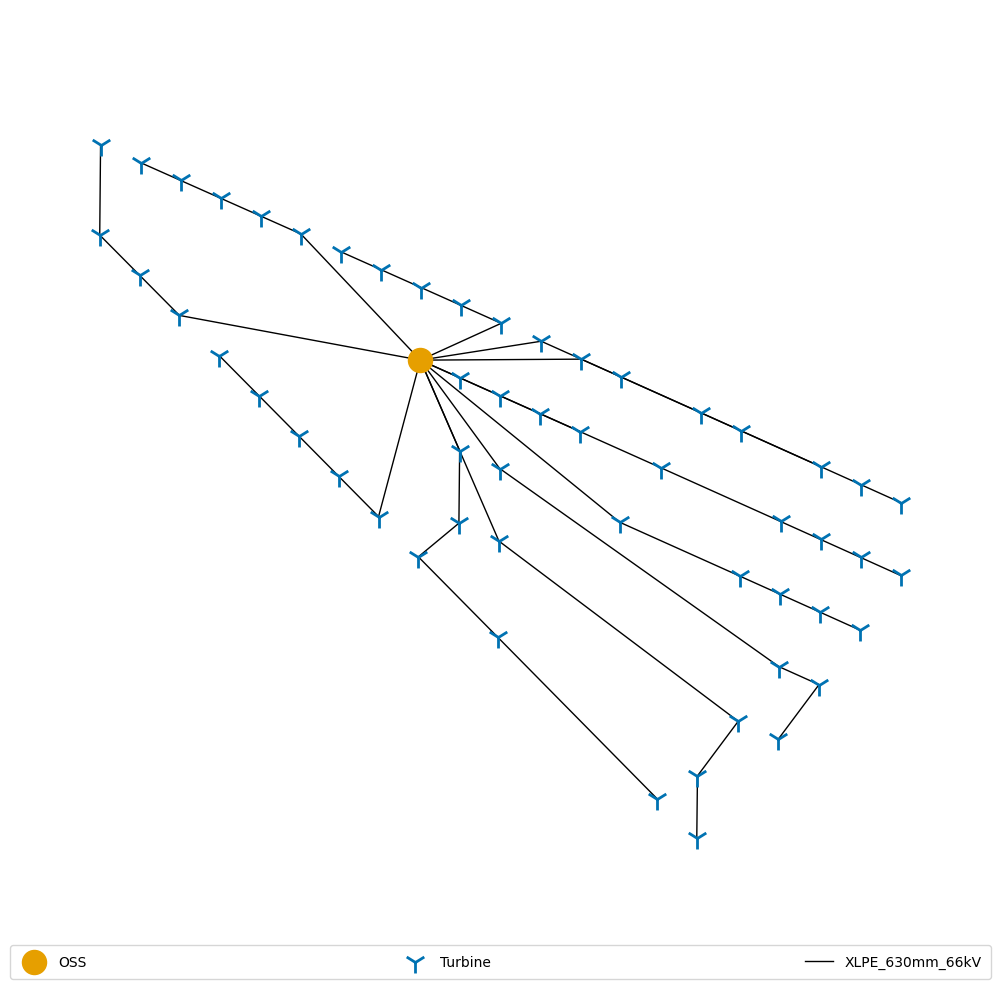

In [9]:
project.phases['CustomArraySystemDesign'].plot_array_system(show=True)

### Installation Actions

In [10]:
df = pd.DataFrame(project.actions)    # The project simulation logs are also available for all modules
df

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height
0,0.5,Array Cable Installation Vessel,Mobilize,72.000000,3.617565e+05,ACTION,0.000000,ArrayCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5,Export Cable Installation Vessel,Mobilize,72.000000,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5,Export Cable Burial Vessel,Mobilize,72.000000,3.617565e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Onshore Construction,Onshore Construction,0.000000,1.226009e+07,ACTION,0.000000,ExportCableInstallation,Landfall,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5,Heavy Lift Vessel,Mobilize,72.000000,9.369180e+05,ACTION,0.000000,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3602,NaN,Array Cable Installation Vessel,Pull In Cable,5.500000,5.526835e+04,ACTION,4437.326020,ArrayCableInstallation,NaN,ArrayCableInstallation,NaN,NaN,NaN,NaN,NaN
3603,NaN,Array Cable Installation Vessel,Terminate Cable,5.500000,5.526835e+04,ACTION,4442.826020,ArrayCableInstallation,NaN,ArrayCableInstallation,NaN,NaN,NaN,NaN,NaN
3604,NaN,Heavy Lift Vessel,Transit,871.714286,2.268680e+07,ACTION,4842.377776,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3605,NaN,Feeder 0,Transit,1017.000000,6.239253e+06,ACTION,4976.783490,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# These logs can be sorted by phase by using DataFrame operations

turbine_install = df.loc[df['phase']=="TurbineInstallation"]
turbine_install

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height
312,1.0,WTIV,Mobilize,168.000000,4.372284e+06,ACTION,964.924351,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
313,0.5,Feeder 0,Mobilize,72.000000,1.405380e+05,ACTION,964.924351,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
314,0.5,Feeder 1,Mobilize,72.000000,1.405380e+05,ACTION,964.924351,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN
318,NaN,Feeder 0,Fasten Tower Section,4.000000,1.561533e+04,ACTION,968.924351,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,NaN,NaN
323,NaN,Feeder 0,Fasten Tower Section,4.000000,1.561533e+04,ACTION,972.924351,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3586,NaN,Feeder 1,Jackdown,1.666667,6.506389e+03,ACTION,4314.901018,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,NaN,NaN
3587,NaN,WTIV,Attach Blade,3.500000,9.108925e+04,ACTION,4318.234351,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.9,150.0
3588,NaN,WTIV,Jackdown,1.496667,3.895150e+04,ACTION,4319.731018,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,34.9,150.0
3589,NaN,Feeder 1,Transit,12.500000,4.879792e+04,ACTION,4327.401018,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Operations can also be grouped to see a total amount of time spend on each operation

turbine_install.groupby(["action"]).sum()['duration']

action
ActiveFeeder                              3317.643333
Attach Blade                               567.000000
Attach Nacelle                             324.000000
Attach Tower Section                       648.000000
Delay                                      341.000000
Delay: Not enough vessels for turbines      19.952381
Fasten Blade                               243.000000
Fasten Nacelle                             216.000000
Fasten Tower Section                       432.000000
Jackdown                                   170.820000
Jackup                                     170.820000
Lift Blade                                 243.000000
Lift Nacelle                                81.000000
Lift Tower Section                         121.500000
Mobilize                                   312.000000
Position Onsite                            108.000000
Queue                                      903.566667
Reequip                                    108.000000
Release Blade        